Importar librerías y dataset

In [2]:
import os
import pandas as pd

#Import the dataset
dataset = os.path.join('..','CTC_processed.csv')
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

data.head(10)

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure,month,day,hour,minute
0,65.0,17.6,24.1,100,55.0,0.0,29.9,1,24,13,12
1,70.0,17.6,22.5,105,54.0,0.0,29.9,1,24,13,17
2,82.0,17.7,17.7,114,53.0,0.0,29.9,1,24,13,27
3,78.0,17.7,27.4,105,53.0,0.0,29.9,1,24,13,32
4,69.0,17.9,27.4,97,52.0,0.0,29.9,1,24,13,37
5,70.0,18.1,14.5,105,51.0,0.0,29.9,1,24,13,52
6,68.0,18.1,22.5,104,51.0,0.0,29.9,1,24,14,2
7,60.0,18.1,17.7,97,52.0,0.0,29.9,1,24,14,10
8,61.0,18.0,19.3,95,52.0,0.0,29.9,1,24,14,15
9,62.0,18.0,20.9,93,52.0,0.0,29.9,1,24,14,20


Separamos las variables predictoras y objetivo.

In [2]:
#Eliminamos filas con valores NaN antes de dividir en train y test
df_clean = data.dropna(subset=['Power_gen'])
predictors = df_clean.drop(columns=['Power_gen'])
objective = df_clean['Power_gen']

Dividimos los datos en train y test

In [3]:
#Dividimos los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors, objective, test_size=0.2, random_state=42) #20% para test

Calculamos los parámetros óptimos del modelo.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2, 5, 9], #profundidad maxima del arbol
          'n_estimators': [50, 100, 900], #numero de arboles
          'max_features': [1, 'sqrt', None]}
pruebas = RandomForestRegressor()
grid = GridSearchCV(pruebas, params, scoring='neg_root_mean_squared_error', cv=2, verbose=2) #calculamos el valor optimo de los parametros
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 2 folds for each of 27 candidates, totalling 54 fits
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=2, max_features=1, n_estimators=100; total time=   0.2s
[CV] END ......max_depth=2, max_features=1, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=2, max_features=1, n_estimators=900; total time=   1.6s
[CV] END ......max_depth=2, max_features=1, n_estimators=900; total time=   1.6s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=900; total time=   2.6s
[CV] END ...max_depth=2, max_features=sqrt, n_es

Creamos el modelo.

In [5]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth = 9, max_features = None,n_estimators = 900) #aplicamos los parametros optimos obtenidos
rfr.fit(X_train, y_train)  #entrenamos el modelo

,n_estimators,900
,criterion,'squared_error'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Predicción y análisis

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = rfr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r2_ajustado = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("MAE: ", mae) #MAE = Error medio en la prediccion
print("MSE:", mse) #MSE = Error cuadratico medio en la prediccion
print("RMSE:", rmse) #RMSE = Raiz del error cuadratico medio en la prediccion
print("R²:", r2) #R^2 = Coeficiente de determinacion
print("R2 ajustado:", r2_ajustado) #R^2 ajustado, si es parecido al normal indica que no hay overfitting ni variables irrelevantes

MAE:  13.436954350213163
MSE: 1500.302462380399
RMSE: 38.733738037793344
R²: 0.9397414930450536
R2 ajustado: 0.9396693617223879


Obtener varaibles más importantes en la predicción

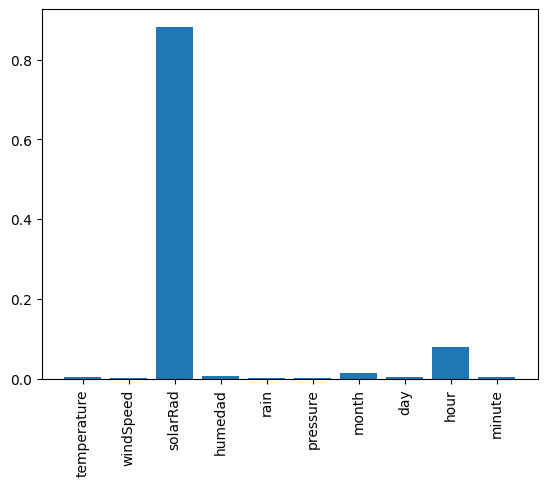

In [7]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, rfr.feature_importances_)
plt.xticks(rotation=90)
plt.show()

Comparativa predicción vs realidad

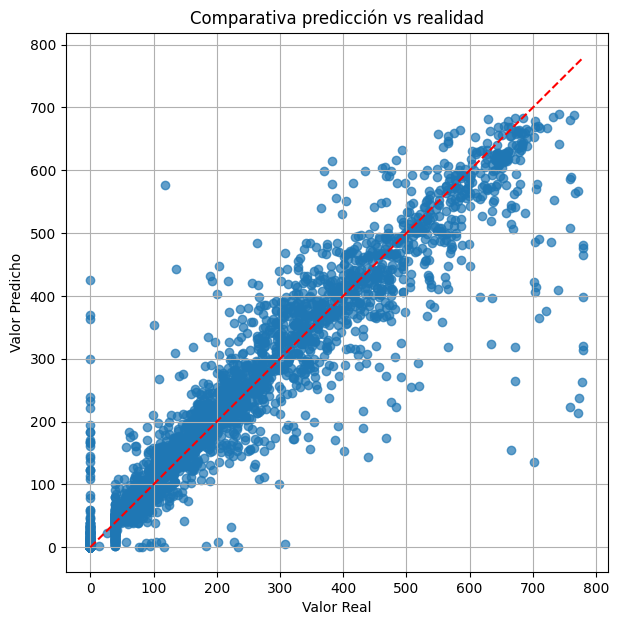

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()
